### Setup Apache Spark

#### Import PySpark dan Membuat Spark Session

In [ ]:
# Jika belum install dependency, jalankan sekali:
# %pip install -r requirements.txt

# Setup Hadoop Home untuk Windows agar tidak error saat export model
import os
import sys
import urllib.request
from pathlib import Path

PROJECT_DIR = Path.cwd()

if os.name == "nt":
    hadoop_home = PROJECT_DIR / "hadoop"
    hadoop_bin = hadoop_home / "bin"
    hadoop_bin.mkdir(parents=True, exist_ok=True)

    winutils_url = "https://raw.githubusercontent.com/cdarlint/winutils/master/hadoop-3.3.5/bin/winutils.exe"
    hadoop_dll_url = "https://raw.githubusercontent.com/cdarlint/winutils/master/hadoop-3.3.5/bin/hadoop.dll"

    winutils_path = hadoop_bin / "winutils.exe"
    hadoop_dll_path = hadoop_bin / "hadoop.dll"

    if not winutils_path.exists():
        print("Downloading winutils.exe...")
        urllib.request.urlretrieve(winutils_url, winutils_path)
    if not hadoop_dll_path.exists():
        print("Downloading hadoop.dll...")
        urllib.request.urlretrieve(hadoop_dll_url, hadoop_dll_path)

    os.environ["HADOOP_HOME"] = str(hadoop_home)
    os.environ["PATH"] = f"{hadoop_bin}{os.pathsep}{os.environ.get('PATH', '')}"

# Pastikan PySpark memakai Python yang sama dengan kernel notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Import library
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    NumericType,
    StringType,
    DoubleType,
    FloatType
)

# Menghentikan SparkSession lama jika cell dijalankan ulang.
# Kadang variabel spark masih ada, tetapi JVM Spark sudah mati; kondisi itu aman untuk diabaikan.
try:
    spark.stop()
except Exception:
    pass

# Membuat SparkSession
spark = (
    SparkSession.builder
    .appName("DDoS SDN Detection using Spark LSH-KNN")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "4g")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

# Mengurangi pesan log Spark yang tidak diperlukan
spark.sparkContext.setLogLevel("WARN")

print("PySpark berhasil di-install dan library berhasil di-import.")
print("SparkSession berhasil dibuat.")

#### Menampilkan Informasi Spark

In [ ]:
# Menampilkan informasi SparkSession yang sedang aktif
print("=" * 50)
print("INFORMASI APACHE SPARK")
print("=" * 50)

print(f"Nama aplikasi       : {spark.sparkContext.appName}")
print(f"Versi Spark         : {spark.version}")
print(f"Master Spark        : {spark.sparkContext.master}")
print(f"Default parallelism : {spark.sparkContext.defaultParallelism}")
print(f"Shuffle partitions  : {spark.conf.get('spark.sql.shuffle.partitions')}")

print("=" * 50)

INFORMASI APACHE SPARK
Nama aplikasi       : DDoS SDN Detection using Spark LSH-KNN
Versi Spark         : 4.1.2
Master Spark        : local[*]
Default parallelism : 16
Shuffle partitions  : 4


### Load Dataset

#### Upload Dataset and Load ke Spark DataFrame

In [ ]:
import os

# Path dataset CSV
dataset_path = "dataset_sdn.csv"

# Membaca dataset sebagai Spark DataFrame
df_raw = spark.read.csv(
    dataset_path,
    header=True,
    inferSchema=True
)

# Menghitung ukuran file
dataset_size_mb = os.path.getsize(dataset_path) / (1024 * 1024)

print("=" * 50)
print("LOAD DATASET")
print("=" * 50)
print("Dataset berhasil dibaca sebagai Spark DataFrame")
print("Nama file          :", os.path.basename(dataset_path))
print("Ukuran file        :", round(dataset_size_mb, 2), "MB")
print("Jumlah kolom       :", len(df_raw.columns))
print("Jumlah partisi awal:", df_raw.rdd.getNumPartitions())

print("\nSchema Dataset:")
df_raw.printSchema()

print("=" * 50)

LOAD DATASET
Dataset berhasil dibaca sebagai Spark DataFrame
Nama file          : dataset_sdn.csv
Ukuran file        : 11.98 MB
Jumlah kolom       : 23
Jumlah partisi awal: 3

Schema Dataset:
root
 |-- dt: integer (nullable = true)
 |-- switch: integer (nullable = true)
 |-- src: string (nullable = true)
 |-- dst: string (nullable = true)
 |-- pktcount: integer (nullable = true)
 |-- bytecount: integer (nullable = true)
 |-- dur: integer (nullable = true)
 |-- dur_nsec: integer (nullable = true)
 |-- tot_dur: double (nullable = true)
 |-- flows: integer (nullable = true)
 |-- packetins: integer (nullable = true)
 |-- pktperflow: integer (nullable = true)
 |-- byteperflow: integer (nullable = true)
 |-- pktrate: integer (nullable = true)
 |-- Pairflow: integer (nullable = true)
 |-- Protocol: string (nullable = true)
 |-- port_no: integer (nullable = true)
 |-- tx_bytes: integer (nullable = true)
 |-- rx_bytes: integer (nullable = true)
 |-- tx_kbps: integer (nullable = true)
 |-- rx_kb

### Repartition Dataset

#### Menetapkan Jumlah Partition

In [ ]:
target_partitions = 4

print("=" * 50)
print("REPARTITION DATASET")
print("=" * 50)

print(f"Jumlah partisi sebelum : {df_raw.rdd.getNumPartitions()}")

# Membuat DataFrame baru tanpa menimpa data awal
df = df_raw.repartition(target_partitions).cache()

total_rows = df.count()

print(f"Jumlah partisi sesudah : {df.rdd.getNumPartitions()}")
print(f"Total data             : {total_rows:,} baris")

partition_counts = (
    df.select(F.spark_partition_id().alias("partition_id"))
    .groupBy("partition_id")
    .count()
    .orderBy("partition_id")
    .collect()
)

print("\nDistribusi Data per Partisi:")
for row in partition_counts:
    print(
        f"Partisi {row['partition_id'] + 1}: "
        f"{row['count']:,} baris"
    )

print("=" * 50)

REPARTITION DATASET
Jumlah partisi sebelum : 3
Jumlah partisi sesudah : 4
Total data             : 104,345 baris

Distribusi Data per Partisi:
Partisi 1: 26,086 baris
Partisi 2: 26,088 baris
Partisi 3: 26,086 baris
Partisi 4: 26,085 baris


### EDA

#### Mengecek Dimensi Dataset

In [ ]:
jumlah_baris = df.count()
jumlah_kolom = len(df.columns)

print("Dimensi Dataset")
print("Jumlah baris:", jumlah_baris)
print("Jumlah kolom:", jumlah_kolom)

print("\nDaftar kolom:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Dimensi Dataset
Jumlah baris: 104345
Jumlah kolom: 23

Daftar kolom:
1. dt
2. switch
3. src
4. dst
5. pktcount
6. bytecount
7. dur
8. dur_nsec
9. tot_dur
10. flows
11. packetins
12. pktperflow
13. byteperflow
14. pktrate
15. Pairflow
16. Protocol
17. port_no
18. tx_bytes
19. rx_bytes
20. tx_kbps
21. rx_kbps
22. tot_kbps
23. label


#### Melihat Distribusi Label

In [ ]:
label_col = "label"

total_data = df.count()

label_distribution = df.groupBy(label_col) \
    .count() \
    .withColumn("percentage", F.round((F.col("count") / total_data) * 100, 2)) \
    .orderBy(label_col)

print("Distribusi Label")
print("Keterangan label:")
print("0 = benign / normal")
print("1 = malicious / serangan")

label_distribution.show()

Distribusi Label
Keterangan label:
0 = benign / normal
1 = malicious / serangan
+-----+-----+----------+
|label|count|percentage|
+-----+-----+----------+
|    0|63561|     60.91|
|    1|40784|     39.09|
+-----+-----+----------+



#### Mengecek Fitur Kategorikal

In [ ]:
numeric_cols = [
    field.name for field in df.schema.fields
    if isinstance(field.dataType, NumericType)
]

categorical_cols = [
    field.name for field in df.schema.fields
    if isinstance(field.dataType, StringType)
]

print("Fitur Numerik dan Kategorikal")
print("Jumlah fitur numerik:", len(numeric_cols))
print("Jumlah fitur kategorikal:", len(categorical_cols))

print("\nFitur numerik:")
for col in numeric_cols:
    print("-", col)

print("\nFitur kategorikal:")
for col in categorical_cols:
    print("-", col)

Fitur Numerik dan Kategorikal
Jumlah fitur numerik: 20
Jumlah fitur kategorikal: 3

Fitur numerik:
- dt
- switch
- pktcount
- bytecount
- dur
- dur_nsec
- tot_dur
- flows
- packetins
- pktperflow
- byteperflow
- pktrate
- Pairflow
- port_no
- tx_bytes
- rx_bytes
- tx_kbps
- rx_kbps
- tot_kbps
- label

Fitur kategorikal:
- src
- dst
- Protocol


#### Cek Missing Value

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, FloatType, StringType

checks = []

for field in df.schema.fields:
    kondisi = F.col(field.name).isNull()

    if isinstance(field.dataType, (DoubleType, FloatType)):
        kondisi = kondisi | F.isnan(field.name)
    elif isinstance(field.dataType, StringType):
        kondisi = kondisi | (F.trim(F.col(field.name)) == "")

    checks.append(
        F.sum(F.when(kondisi, 1).otherwise(0)).alias(field.name)
    )

hasil_missing = df.select(checks).first()

print("Jumlah Missing Value:")
for kolom, jumlah in hasil_missing.asDict().items():
    print(f"{kolom}: {jumlah}")

Jumlah Missing Value:
dt: 0
switch: 0
src: 0
dst: 0
pktcount: 0
bytecount: 0
dur: 0
dur_nsec: 0
tot_dur: 0
flows: 0
packetins: 0
pktperflow: 0
byteperflow: 0
pktrate: 0
Pairflow: 0
Protocol: 0
port_no: 0
tx_bytes: 0
rx_bytes: 0
tx_kbps: 0
rx_kbps: 506
tot_kbps: 506
label: 0


#### Cek Data Duplikat

In [ ]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()
duplicate_rows = total_rows - unique_rows
duplicate_percentage = (duplicate_rows / total_rows) * 100

print("Cek Data Duplikat")
print("Total data:", total_rows)
print("Data unik:", unique_rows)
print("Data duplikat:", duplicate_rows)
print("Persentase duplikat:", round(duplicate_percentage, 2), "%")

Cek Data Duplikat
Total data: 104345
Data unik: 99254
Data duplikat: 5091
Persentase duplikat: 4.88 %


### Preprocessing

In [ ]:
spark_ui_url = spark.sparkContext.uiWebUrl

if spark_ui_url:
    print("Spark UI:", spark_ui_url)
else:
    print("Spark UI tidak aktif")

Spark UI: http://LAPTOP-GLIOI2SL:4040


#### Hapus Data Duplikat

In [ ]:
import time

start_time = time.perf_counter()

print("Hapus Data Duplikat")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Hapus Duplikat - Hitung Data Sebelum"
)
data_sebelum = df.count()

spark.sparkContext.setJobDescription(
    "Hapus Duplikat - Proses dan Hitung Data Sesudah"
)
df_bersih = df.dropDuplicates().cache()
data_sesudah = df_bersih.count()

df.unpersist()
df = df_bersih

waktu_eksekusi = time.perf_counter() - start_time

print("Status: selesai")
print("Jumlah data sebelum:", data_sebelum)
print("Jumlah data sesudah:", data_sesudah)
print("Data duplikat dihapus:", data_sebelum - data_sesudah)
print("Jumlah partisi:", df.rdd.getNumPartitions())
print("Waktu eksekusi:", round(waktu_eksekusi, 2), "detik")

Hapus Data Duplikat
Status: berjalan...
Status: selesai
Jumlah data sebelum: 104345
Jumlah data sesudah: 99254
Data duplikat dihapus: 5091
Jumlah partisi: 4
Waktu eksekusi: 36.1 detik


#### Split Train-Test

In [ ]:
import time

start_time = time.perf_counter()

print("Split Data Train dan Test")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Preprocessing - Split Data Train dan Test"
)

# Menghapus baris dengan label kosong
df = df.dropna(subset=["label"])

# Membagi data menjadi 80% train dan 20% test
train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

# Menyimpan hasil split agar tidak dihitung ulang
train_df = train_df.cache()
test_df = test_df.cache()

jumlah_train = train_df.count()
jumlah_test = test_df.count()
total_data = jumlah_train + jumlah_test

print("Status: selesai")
print("Jumlah data train:", jumlah_train)
print("Jumlah data test:", jumlah_test)
print("Total data:", total_data)
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Split Data Train dan Test
Status: berjalan...
Status: selesai
Jumlah data train: 79589
Jumlah data test: 19665
Total data: 99254
Waktu eksekusi: 13.01 detik


#### Menangani Missing Value

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType, DoubleType, FloatType
import time

start_time = time.perf_counter()

print("Menangani Missing Value")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Preprocessing - Menangani Missing Value"
)

numeric_cols = [
    f.name for f in train_df.schema.fields
    if isinstance(f.dataType, NumericType) and f.name != "label"
]

categorical_cols = [
    f.name for f in train_df.schema.fields
    if isinstance(f.dataType, StringType)
]

float_cols = [
    f.name for f in train_df.schema.fields
    if isinstance(f.dataType, (DoubleType, FloatType))
]

# Mengubah NaN dan Infinity menjadi null
for col in float_cols:
    invalid = F.isnan(col) | F.col(col).isin(float("inf"), float("-inf"))

    train_df = train_df.withColumn(
        col, F.when(invalid, None).otherwise(F.col(col))
    )
    test_df = test_df.withColumn(
        col, F.when(invalid, None).otherwise(F.col(col))
    )

# Menghitung median dari data train
median_result = train_df.approxQuantile(numeric_cols, [0.5], 0.01)

median_values = {
    col: nilai[0] if nilai else 0
    for col, nilai in zip(numeric_cols, median_result)
}

# Mengisi missing value train dan test
train_df = train_df.fillna(median_values)
test_df = test_df.fillna(median_values)

train_df = train_df.fillna("unknown", subset=categorical_cols)
test_df = test_df.fillna("unknown", subset=categorical_cols)

train_df.cache().count()
test_df.cache().count()

print("Status: selesai")
print("Kolom numerik ditangani:", len(numeric_cols))
print("Kolom kategorikal ditangani:", len(categorical_cols))
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Menangani Missing Value
Status: berjalan...
Status: selesai
Kolom numerik ditangani: 19
Kolom kategorikal ditangani: 3
Waktu eksekusi: 6.69 detik


#### Encoding Fitur Kategorikal

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.sql.types import StringType
import time

start_time = time.perf_counter()

print("Encoding Fitur Kategorikal")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Preprocessing - Encoding Fitur Kategorikal"
)

categorical_cols = [
    f.name for f in train_df.schema.fields
    if isinstance(f.dataType, StringType)
]

indexed_cols = [f"{col}_index" for col in categorical_cols]

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

encoding_model = Pipeline(stages=indexers).fit(train_df)

train_encoded = encoding_model.transform(train_df).cache()
test_encoded = encoding_model.transform(test_df).cache()

print("Status: selesai")
print("Fitur kategorikal:", categorical_cols)
print("Fitur hasil encoding:", indexed_cols)
print("Data train:", train_encoded.count())
print("Data test:", test_encoded.count())
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Encoding Fitur Kategorikal
Status: berjalan...
Status: selesai
Fitur kategorikal: ['src', 'dst', 'Protocol']
Fitur hasil encoding: ['src_index', 'dst_index', 'Protocol_index']
Data train: 79589
Data test: 19665
Waktu eksekusi: 3.34 detik


#### Vectorisasi dan Standardisasi Fitur

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.types import NumericType
import time

start_time = time.perf_counter()

print("Vectorisasi dan Standardisasi Fitur")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Preprocessing - Vectorisasi dan Standardisasi Fitur"
)

# Kolom identitas/waktu dikeluarkan agar model tidak sekadar menghafal pola IP, switch, atau urutan waktu.
excluded_feature_cols = ["dt", "switch", "src", "dst"]
excluded_indexed_cols = [f"{col}_index" for col in excluded_feature_cols]

numeric_cols = [
    f.name for f in train_encoded.schema.fields
    if isinstance(f.dataType, NumericType)
    and f.name != "label"
    and not f.name.endswith("_index")
    and f.name not in excluded_feature_cols
]

selected_indexed_cols = [
    col for col in indexed_cols
    if col not in excluded_indexed_cols
]

feature_cols = numeric_cols + selected_indexed_cols

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

train_vector = assembler.transform(train_encoded)
test_vector = assembler.transform(test_encoded)

scaler_model = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
).fit(train_vector)

train_scaled = scaler_model.transform(train_vector).select("features", "label").cache()
test_scaled = scaler_model.transform(test_vector).select("features", "label").cache()

print("Status: selesai")
print("Kolom dikeluarkan:", excluded_feature_cols)
print("Total fitur:", len(feature_cols))
print("Data train:", train_scaled.count())
print("Data test:", test_scaled.count())
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Vectorisasi dan Standardisasi Fitur
Status: berjalan...
Status: selesai
Kolom dikeluarkan: ['dt', 'switch', 'src', 'dst']
Total fitur: 18
Data train: 79589
Data test: 19665
Waktu eksekusi: 2.25 detik


### Modelling

#### Menentukan Parameter LSH-KNN

In [ ]:
print("Parameter LSH-KNN")

k = 3
bucket_length = 1.0
num_hash_tables = 2
prediction_sample_size = 5000
distance_threshold = 1.5
lsh_train_fraction = 0.35
balanced_prediction_sample = True
seed = 42

print("Nilai k:", k)
print("Bucket length:", bucket_length)
print("Jumlah hash table:", num_hash_tables)
print("Sample data test:", prediction_sample_size)
print("Distance threshold:", distance_threshold)
print("LSH train fraction:", lsh_train_fraction)
print("Balanced sample:", balanced_prediction_sample)

Parameter LSH-KNN
Nilai k: 3
Bucket length: 1.0
Jumlah hash table: 2
Sample data test: 5000
Distance threshold: 1.5
LSH train fraction: 0.35
Balanced sample: True


#### Fit LSH pada Data Train

In [ ]:
from pyspark.ml.feature import BucketedRandomProjectionLSH
import time

start_time = time.perf_counter()

print("Fit LSH pada Data Train")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Modelling - Fit LSH pada Data Train"
)

lsh = BucketedRandomProjectionLSH(
    inputCol="features",
    outputCol="hashes",
    bucketLength=bucket_length,
    numHashTables=num_hash_tables,
    seed=seed
)

lsh_model = lsh.fit(train_scaled)

print("Status: selesai")
print("Metode: Bucketed Random Projection LSH")
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Fit LSH pada Data Train
Status: berjalan...
Status: selesai
Metode: Bucketed Random Projection LSH
Waktu eksekusi: 0.18 detik


#### Transformasi Data Train Menggunakan LSH

In [ ]:
import time

start_time = time.perf_counter()

print("Transform Data Train Menggunakan LSH")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Modelling - Transform Data Train Menggunakan LSH"
)

train_hashed = (
    lsh_model.transform(
        train_scaled.sample(
            withReplacement=False,
            fraction=lsh_train_fraction,
            seed=seed
        )
    )
    .select("features", "label", "hashes")
    .cache()
)

jumlah_train = train_hashed.count()

print("Status: selesai")
print("Fraction data train LSH:", lsh_train_fraction)
print("Jumlah data train:", jumlah_train)
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

Transform Data Train Menggunakan LSH
Status: berjalan...
Status: selesai
Fraction data train LSH: 0.35
Jumlah data train: 27931
Waktu eksekusi: 0.64 detik


#### Prediksi Data Test menggunakan LSH-KNN

In [ ]:
from functools import reduce
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StructField, StructType
from pyspark.sql.window import Window
import time

start_time = time.perf_counter()
batch_size = 50

print("Prediksi Data Test Menggunakan LSH-KNN")
print("Status: berjalan...")

spark.sparkContext.setJobDescription(
    "Modelling - Prediksi LSH-KNN"
)

if balanced_prediction_sample:
    sample_per_label = max(1, prediction_sample_size // 2)
    label_window = Window.partitionBy("label").orderBy(F.rand(seed))

    test_sample = (
        test_scaled
        .withColumn("sample_rank", F.row_number().over(label_window))
        .filter(F.col("sample_rank") <= sample_per_label)
        .drop("sample_rank")
        .orderBy(F.rand(seed))
        .coalesce(1)
        .withColumn("test_id", F.monotonically_increasing_id())
        .cache()
    )
else:
    test_sample = (
        test_scaled
        .orderBy(F.rand(seed))
        .limit(prediction_sample_size)
        .coalesce(1)
        .withColumn("test_id", F.monotonically_increasing_id())
        .cache()
    )

jumlah_sampel = test_sample.count()
hasil_batch = []
default_prediction_label = (
    train_scaled
    .groupBy("label")
    .count()
    .orderBy(F.desc("count"))
    .first()["label"]
)

prediction_schema = StructType([
    StructField("actual_label", DoubleType(), True),
    StructField("predicted_label", DoubleType(), True)
])

for start in range(0, jumlah_sampel, batch_size):
    end = min(start + batch_size, jumlah_sampel)

    test_batch = test_sample.filter(
        (F.col("test_id") >= start) &
        (F.col("test_id") < end)
    )

    pairs = (
        lsh_model.approxSimilarityJoin(
            train_hashed,
            lsh_model.transform(test_batch),
            distance_threshold,
            "distance"
        )
        .select(
            F.col("datasetB.test_id").alias("test_id"),
            F.col("datasetB.label").alias("actual_label"),
            F.col("datasetA.label").alias("neighbor_label"),
            "distance"
        )
    )

    nearest = (
        pairs
        .withColumn(
            "rank",
            F.row_number().over(
                Window.partitionBy("test_id").orderBy("distance")
            )
        )
        .filter(F.col("rank") <= k)
    )

    votes = (
        nearest
        .groupBy("test_id", "actual_label", "neighbor_label")
        .count()
    )

    vote_prediction = (
        votes
        .withColumn(
            "vote_rank",
            F.row_number().over(
                Window.partitionBy("test_id").orderBy(
                    F.desc("count"),
                    F.asc("neighbor_label")
                )
            )
        )
        .filter(F.col("vote_rank") == 1)
        .select(
            "test_id",
            F.col("neighbor_label").cast("double")
            .alias("predicted_label")
        )
    )

    batch_prediction = (
        test_batch
        .select(
            "test_id",
            F.col("label").cast("double").alias("actual_label")
        )
        .join(vote_prediction, on="test_id", how="left")
        .fillna({"predicted_label": float(default_prediction_label)})
        .select("actual_label", "predicted_label")
        .cache()
    )

    jumlah_prediksi_batch = batch_prediction.count()

    if jumlah_prediksi_batch > 0:
        hasil_batch.append(batch_prediction)
    else:
        batch_prediction.unpersist()

    print(f"Proses selesai: {end}/{jumlah_sampel} | prediksi batch: {jumlah_prediksi_batch}")

if hasil_batch:
    prediction_df = reduce(
        lambda df1, df2: df1.unionByName(df2),
        hasil_batch
    ).cache()
else:
    prediction_df = spark.createDataFrame([], prediction_schema).cache()

jumlah_prediksi = prediction_df.count()

for batch in hasil_batch:
    batch.unpersist()

test_sample.unpersist()

print("Status: selesai")
print("Jumlah data diprediksi:", jumlah_prediksi)
print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")

prediction_df.show(10)

Prediksi Data Test Menggunakan LSH-KNN
Status: berjalan...
Proses selesai: 50/5000 | prediksi batch: 50
Proses selesai: 100/5000 | prediksi batch: 50
Proses selesai: 150/5000 | prediksi batch: 50
Proses selesai: 200/5000 | prediksi batch: 50
Proses selesai: 250/5000 | prediksi batch: 50
Proses selesai: 300/5000 | prediksi batch: 50
Proses selesai: 350/5000 | prediksi batch: 50
Proses selesai: 400/5000 | prediksi batch: 50
Proses selesai: 450/5000 | prediksi batch: 50
Proses selesai: 500/5000 | prediksi batch: 50
Proses selesai: 550/5000 | prediksi batch: 50
Proses selesai: 600/5000 | prediksi batch: 50
Proses selesai: 650/5000 | prediksi batch: 50
Proses selesai: 700/5000 | prediksi batch: 50
Proses selesai: 750/5000 | prediksi batch: 50
Proses selesai: 800/5000 | prediksi batch: 50
Proses selesai: 850/5000 | prediksi batch: 50
Proses selesai: 900/5000 | prediksi batch: 50
Proses selesai: 950/5000 | prediksi batch: 50
Proses selesai: 1000/5000 | prediksi batch: 50
Proses selesai: 1050/

### Evaluation

#### Confusion Matrix

In [ ]:
from pyspark.sql import functions as F

m = prediction_df.agg(
    F.sum(F.when((F.col("actual_label") == 1) & (F.col("predicted_label") == 1), 1).otherwise(0)).alias("TP"),
    F.sum(F.when((F.col("actual_label") == 0) & (F.col("predicted_label") == 0), 1).otherwise(0)).alias("TN"),
    F.sum(F.when((F.col("actual_label") == 0) & (F.col("predicted_label") == 1), 1).otherwise(0)).alias("FP"),
    F.sum(F.when((F.col("actual_label") == 1) & (F.col("predicted_label") == 0), 1).otherwise(0)).alias("FN")
).first()

tp, tn, fp, fn = m["TP"], m["TN"], m["FP"], m["FN"]

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if tp + fp > 0 else 0
recall = tp / (tp + fn) if tp + fn > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.954
Precision: 0.971
Recall   : 0.936
F1-Score : 0.9532


Confusion Matrix
Format detail:
+------------+---------------+-----+
|actual_label|predicted_label|count|
+------------+---------------+-----+
|         0.0|            0.0| 2430|
|         0.0|            1.0|   70|
|         1.0|            0.0|  160|
|         1.0|            1.0| 2340|
+------------+---------------+-----+

Tabel Confusion Matrix:
Baris = label aktual, kolom = label prediksi
+------------+------------------+------------------+------------+
|actual_label|predicted_0_normal|predicted_1_attack|total_actual|
+------------+------------------+------------------+------------+
|         0.0|              2430|                70|        2500|
|         1.0|               160|              2340|        2500|
+------------+------------------+------------------+------------+



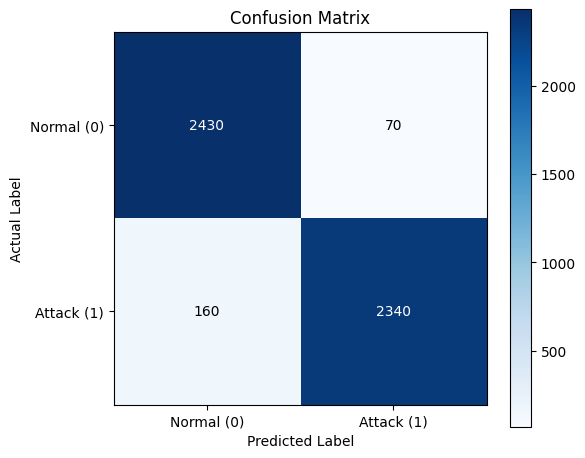

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F

print("Confusion Matrix")

confusion_matrix = (
    prediction_df
    .groupBy("actual_label", "predicted_label")
    .count()
    .orderBy("actual_label", "predicted_label")
)

print("Format detail:")
confusion_matrix.show()

confusion_matrix_table = (
    prediction_df
    .groupBy("actual_label")
    .pivot("predicted_label", [0.0, 1.0])
    .count()
    .fillna(0)
    .withColumnRenamed("0.0", "predicted_0_normal")
    .withColumnRenamed("1.0", "predicted_1_attack")
    .withColumn(
        "total_actual",
        F.col("predicted_0_normal") + F.col("predicted_1_attack")
    )
    .orderBy("actual_label")
)

print("Tabel Confusion Matrix:")
print("Baris = label aktual, kolom = label prediksi")
confusion_matrix_table.show()

cm = prediction_df.agg(
    F.sum(F.when((F.col("actual_label") == 0) & (F.col("predicted_label") == 0), 1).otherwise(0)).alias("TN"),
    F.sum(F.when((F.col("actual_label") == 0) & (F.col("predicted_label") == 1), 1).otherwise(0)).alias("FP"),
    F.sum(F.when((F.col("actual_label") == 1) & (F.col("predicted_label") == 0), 1).otherwise(0)).alias("FN"),
    F.sum(F.when((F.col("actual_label") == 1) & (F.col("predicted_label") == 1), 1).otherwise(0)).alias("TP")
).first()

cm_matrix = np.array([
    [cm["TN"], cm["FP"]],
    [cm["FN"], cm["TP"]]
])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_matrix, cmap="Blues")

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal (0)", "Attack (1)"])
ax.set_yticklabels(["Normal (0)", "Attack (1)"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            int(cm_matrix[i, j]),
            ha="center",
            va="center",
            color="white" if cm_matrix[i, j] > cm_matrix.max() / 2 else "black"
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Analisis Fitur Penting

Analisis Fitur Penting
Metode: Random Forest sebagai model interpretasi pembanding
Top 15 fitur paling penting:
1. byteperflow: 0.237531
2. bytecount: 0.149056
3. pktperflow: 0.139843
4. pktrate: 0.130216
5. pktcount: 0.130002
6. packetins: 0.092391
7. Protocol_index: 0.047801
8. tot_dur: 0.032177
9. dur: 0.014497
10. Pairflow: 0.006968
11. flows: 0.005374
12. tx_bytes: 0.004639
13. dur_nsec: 0.003343
14. tot_kbps: 0.002789
15. rx_bytes: 0.001943


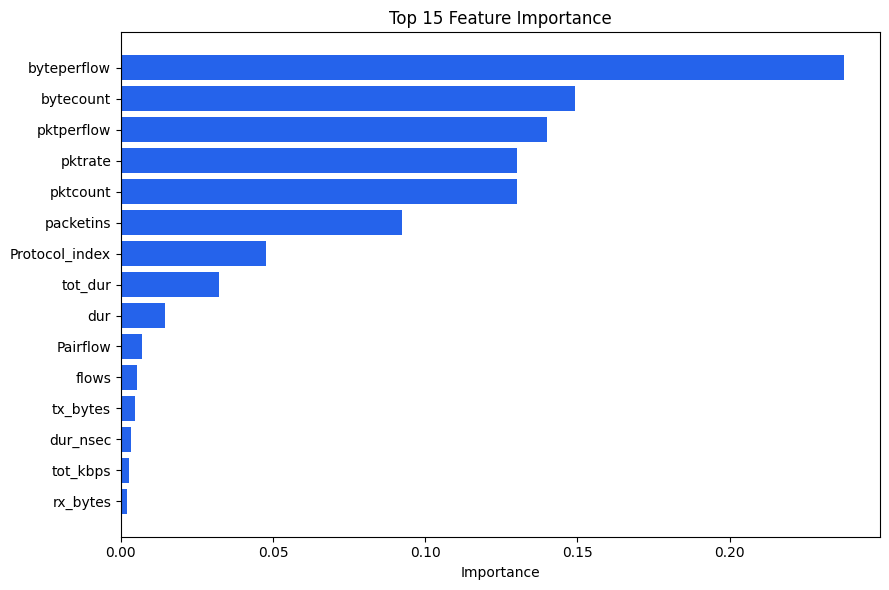

DataFrame[features: vector, label: int]

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
import matplotlib.pyplot as plt

print("Analisis Fitur Penting")
print("Metode: Random Forest sebagai model interpretasi pembanding")

rf_importance_sample_fraction = 0.4

importance_train = (
    train_scaled
    .sample(
        withReplacement=False,
        fraction=rf_importance_sample_fraction,
        seed=seed
    )
    .cache()
)

rf_model = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=8,
    seed=seed
).fit(importance_train)

feature_importance = list(zip(feature_cols, rf_model.featureImportances.toArray()))
feature_importance = sorted(
    feature_importance,
    key=lambda item: item[1],
    reverse=True
)

top_features = feature_importance[:15]

print("Top 15 fitur paling penting:")
for rank, (feature, importance) in enumerate(top_features, start=1):
    print(f"{rank}. {feature}: {importance:.6f}")

features_plot = [item[0] for item in reversed(top_features)]
importance_plot = [item[1] for item in reversed(top_features)]

plt.figure(figsize=(9, 6))
plt.barh(features_plot, importance_plot, color="#2563eb")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

importance_train.unpersist()

#### Export Model

In [ ]:
import json
import os
import time

model_base_path = "exported_lsh_knn_model"

print("Export Model LSH-KNN")
print("Lokasi export:", model_base_path)

if os.path.exists(model_base_path):
    print("Status: dilewati")
    print("Model sudah pernah diexport, sehingga tidak diexport ulang.")
else:
    start_time = time.perf_counter()
    os.makedirs(model_base_path, exist_ok=False)

    encoding_model.write().save(os.path.join(model_base_path, "encoding_model"))
    scaler_model.write().save(os.path.join(model_base_path, "scaler_model"))
    lsh_model.write().save(os.path.join(model_base_path, "lsh_model"))

    train_hashed.write.parquet(
        os.path.join(model_base_path, "train_hashed"),
        mode="error"
    )

    metadata = {
        "model_name": "DDoS SDN Detection using Spark LSH-KNN",
        "label_col": "label",
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "indexed_cols": indexed_cols,
        "parameters": {
            "k": k,
            "bucket_length": bucket_length,
            "num_hash_tables": num_hash_tables,
            "prediction_sample_size": prediction_sample_size,
            "distance_threshold": distance_threshold,
            "lsh_train_fraction": lsh_train_fraction,
            "balanced_prediction_sample": balanced_prediction_sample,
            "seed": seed
        },
        "metrics": {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        }
    }

    with open(os.path.join(model_base_path, "metadata.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print("Status: selesai")
    print("Komponen yang diexport:")
    print("- encoding_model")
    print("- scaler_model")
    print("- lsh_model")
    print("- train_hashed")
    print("- metadata.json")
    print("Waktu eksekusi:", round(time.perf_counter() - start_time, 2), "detik")


Export Model LSH-KNN
Lokasi export: exported_lsh_knn_model
Status: dilewati
Model sudah pernah diexport, sehingga tidak diexport ulang.
